In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("diabetes.csv")
df.head()


Saving diabetes.csv to diabetes.csv


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# 1) Handling Missing Data

In [ ]:
missing_before = df.isnull().sum()
missing_before


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
columns_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns_with_zero:
    print(col, (df[col] == 0).sum())


Glucose 5
BloodPressure 35
SkinThickness 227
Insulin 374
BMI 11


In [ ]:
df[columns_with_zero] = df[columns_with_zero].replace(0, np.nan)
df.isnull().sum()


,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


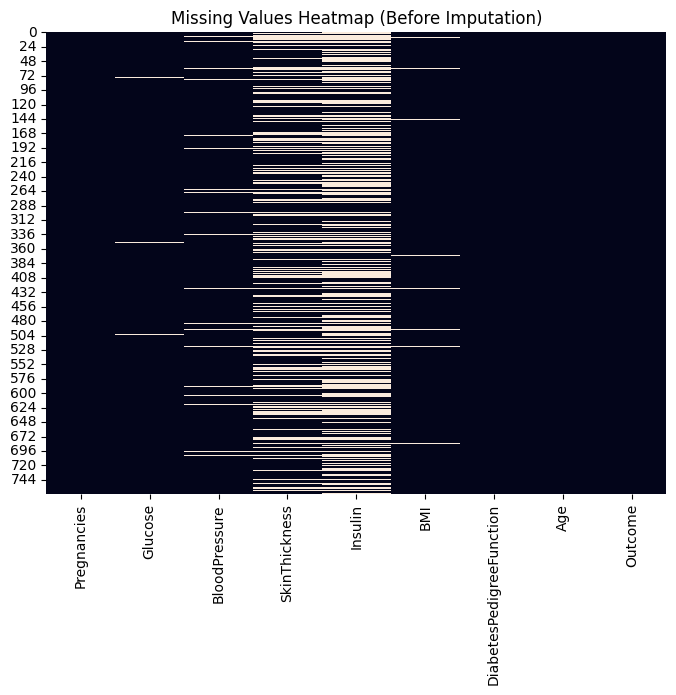

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap (Before Imputation)")
plt.show()


In [ ]:
before_imputation = df.isnull().sum()

for col in columns_with_zero:
    df[col] = df[col].fillna(df[col].median())

after_imputation = df.isnull().sum()
after_imputation


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
comparison_df = pd.DataFrame({
    "Missing Values (Before)": before_imputation,
    "Missing Values (After)": after_imputation
})

comparison_df


,Missing Values (Before),Missing Values (After)
Pregnancies,0,0
Glucose,5,0
BloodPressure,35,0
SkinThickness,227,0
Insulin,374,0
BMI,11,0
DiabetesPedigreeFunction,0,0
Age,0,0
Outcome,0,0


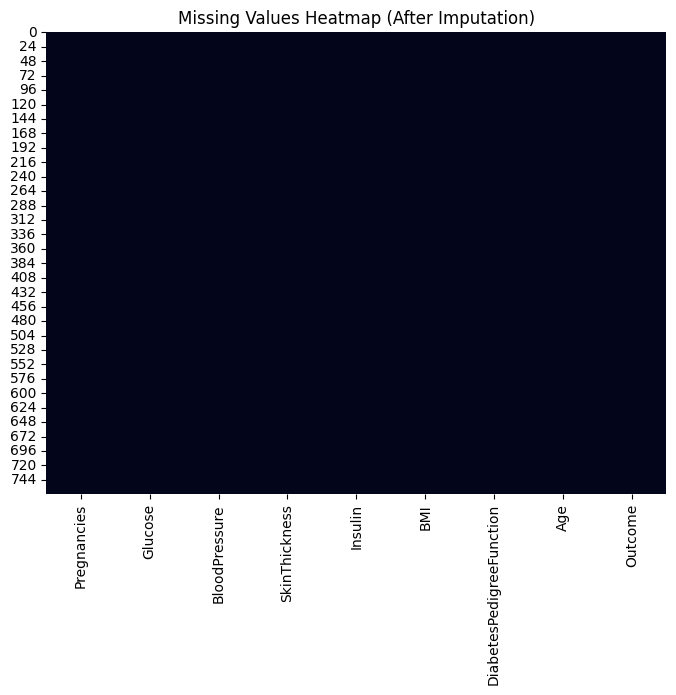

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap (After Imputation)")
plt.show()


### Justification for Missing Data Handling

In this dataset, missing values appeared as zeros in medical features such as
Glucose, BloodPressure, SkinThickness, Insulin, and BMI.
Since zero is not a medically valid value for these measurements,
we treated them as missing values.

We chose Median Imputation instead of Mean because:
- The dataset contains outliers (as shown in boxplots).
- The median is more robust to extreme values.
- It preserves the distribution better than the mean.

Deletion was not used because removing rows would reduce the dataset size
and potentially remove important medical information.


#2) Outlier Treatment



In [ ]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()
df = pd.read_csv("diabetes.csv")


Saving diabetes.csv to diabetes.csv


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


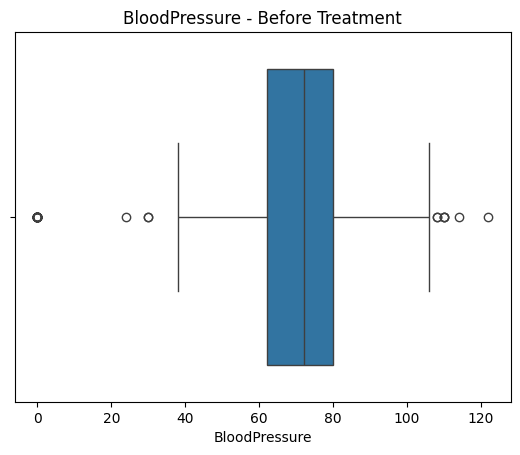

In [ ]:
sns.boxplot(x=df['BloodPressure'])
plt.title('BloodPressure - Before Treatment')
plt.xlabel('BloodPressure')
plt.show()


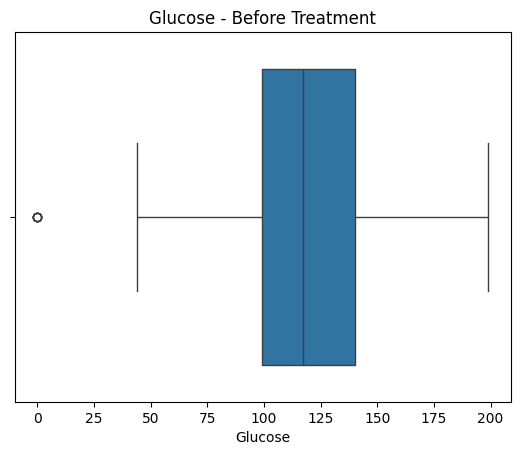

In [ ]:
sns.boxplot(x=df['Glucose'])
plt.title('Glucose - Before Treatment')
plt.xlabel('Glucose')
plt.show()


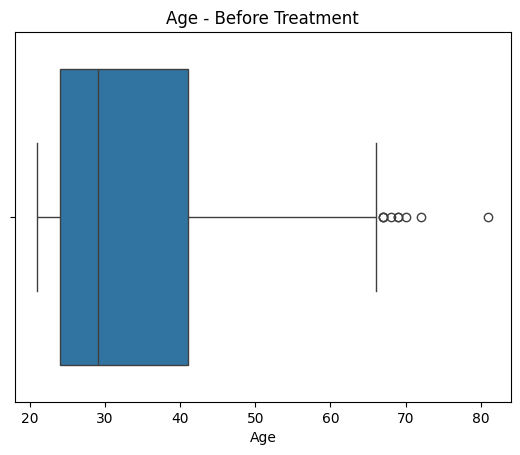

In [ ]:
sns.boxplot(x=df['Age'])
plt.title('Age - Before Treatment')
plt.xlabel('Age')
plt.show()


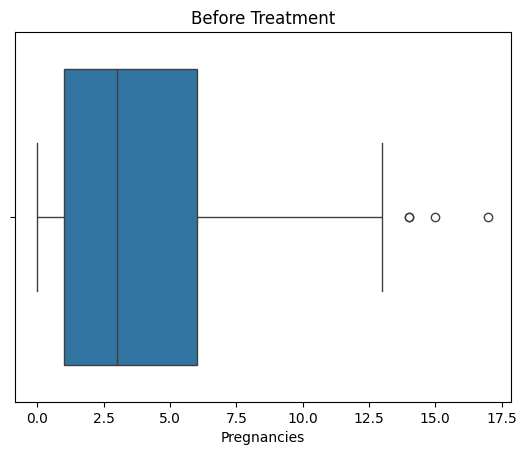

In [ ]:
sns.boxplot(x=df['Pregnancies'])
plt.title('Before Treatment')
plt.show()


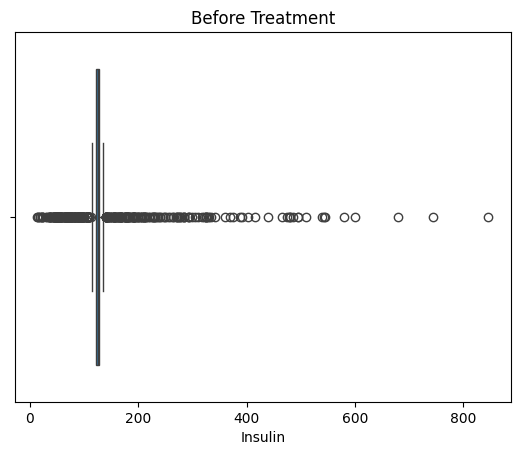

In [ ]:
sns.boxplot(x=df['Insulin'])
plt.title('Before Treatment')
plt.show()


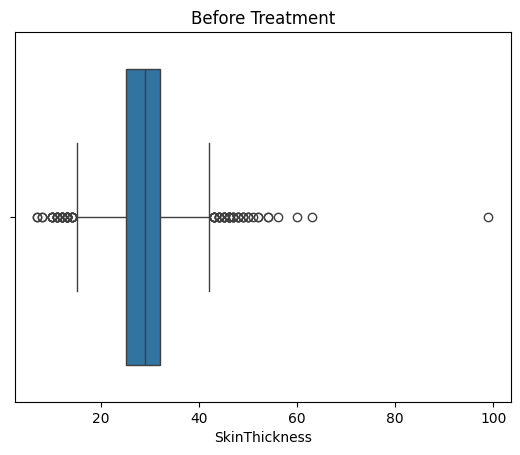

In [ ]:
sns.boxplot(x=df['SkinThickness'])
plt.title('Before Treatment')
plt.show()


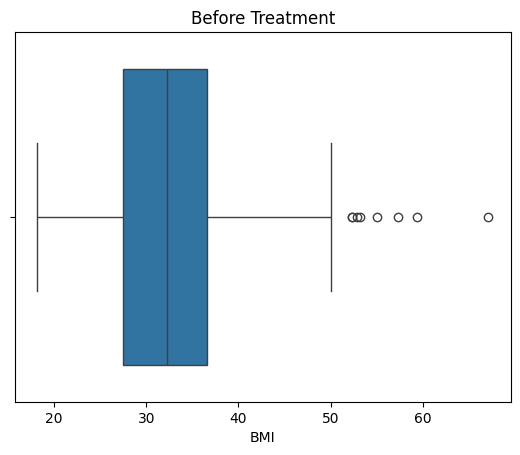

In [ ]:
sns.boxplot(x=df['BMI'])
plt.title('Before Treatment')
plt.show()


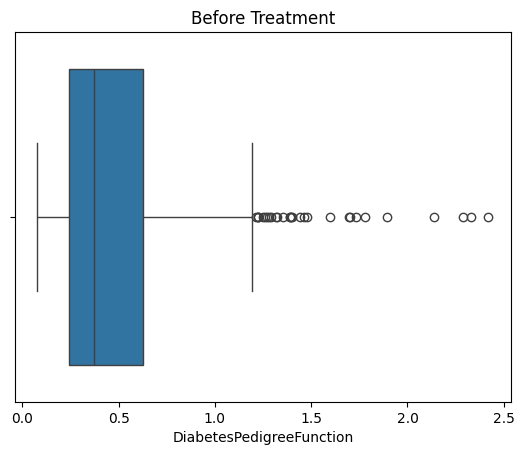

In [ ]:
sns.boxplot(x=df['DiabetesPedigreeFunction'])
plt.title('Before Treatment')
plt.show()


In [ ]:
columns_to_fix = ['Pregnancies', 'Insulin', 'SkinThickness',
                  'BMI', 'DiabetesPedigreeFunction', 'BloodPressure' ,  'Age' , 'Glucose']


In [ ]:
for column in columns_to_fix:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)


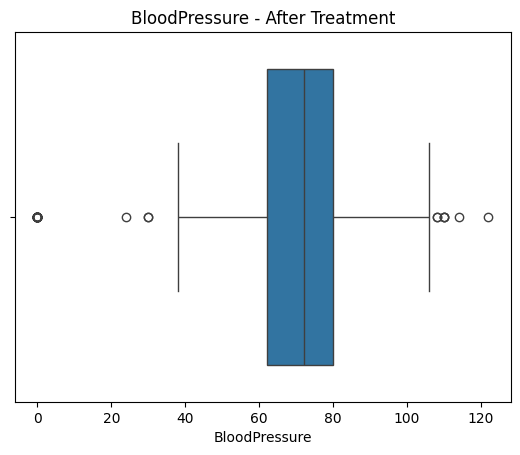

In [ ]:
sns.boxplot(x=df['BloodPressure'])
plt.title('BloodPressure - After Treatment')
plt.xlabel('BloodPressure')
plt.show()


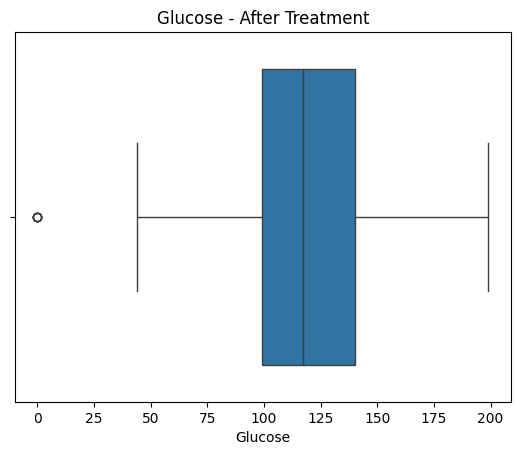

In [ ]:
sns.boxplot(x=df['Glucose'])
plt.title('Glucose - After Treatment')
plt.xlabel('Glucose')
plt.show()


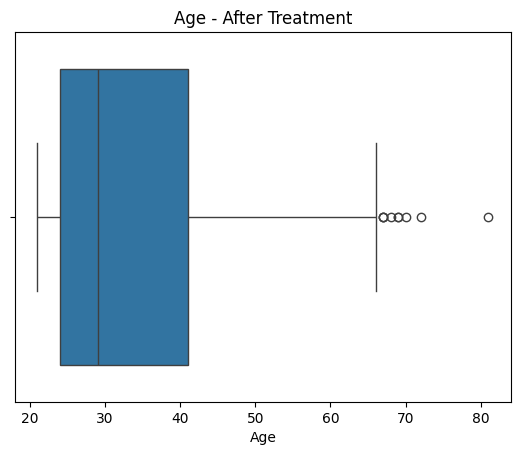

In [ ]:
sns.boxplot(x=df['Age'])
plt.title('Age - After Treatment')
plt.xlabel('Age')
plt.show()


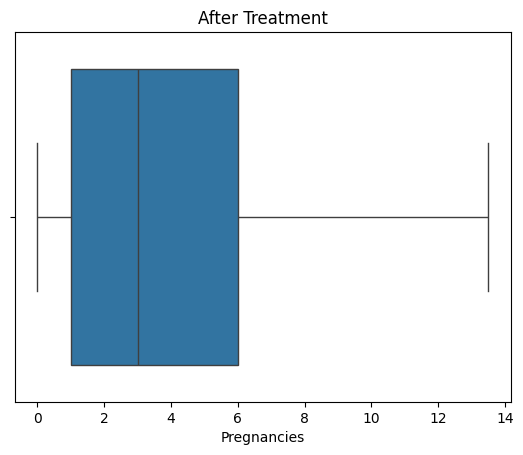

In [ ]:
sns.boxplot(x=df['Pregnancies'])
plt.title('After Treatment')
plt.show()


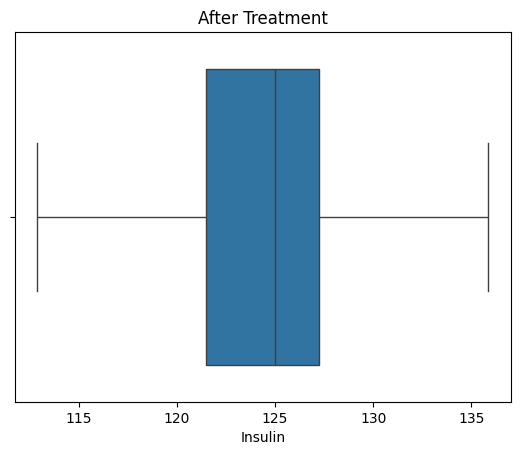

In [ ]:
sns.boxplot(x=df['Insulin'])
plt.title('After Treatment')
plt.show()


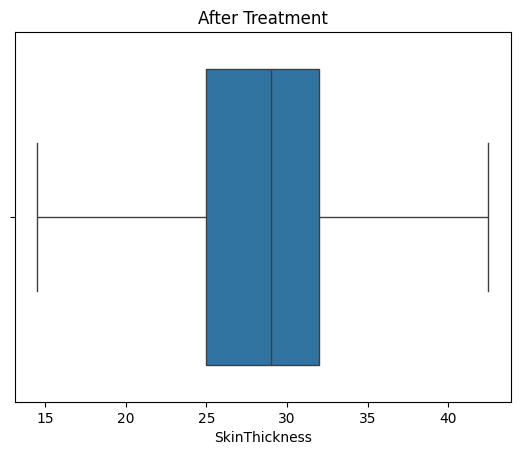

In [ ]:
sns.boxplot(x=df['SkinThickness'])
plt.title('After Treatment')
plt.show()


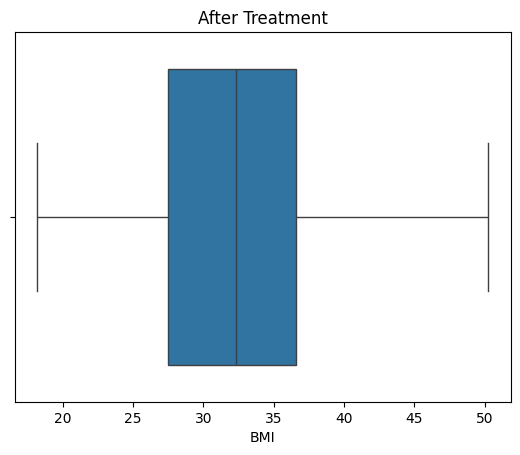

In [ ]:
sns.boxplot(x=df['BMI'])
plt.title('After Treatment')
plt.show()


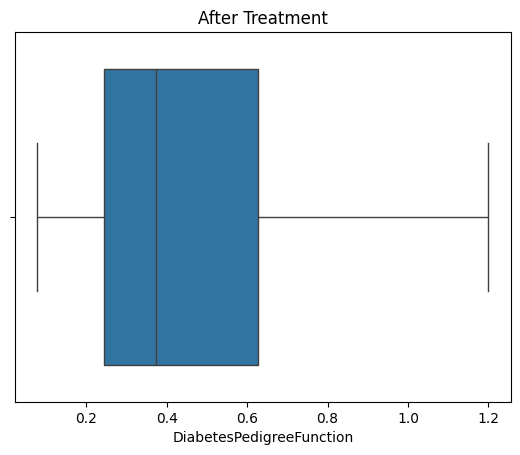

In [ ]:
sns.boxplot(x=df['DiabetesPedigreeFunction'])
plt.title('After Treatment')
plt.show()


In [ ]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.837240,121.656250,72.386719,28.866536,124.691081,32.393359,0.458914,33.240885,0.348958
std,3.344157,30.438286,12.096642,7.442353,7.913595,6.667471,0.285596,11.760232,0.476951
min,0.000000,44.000000,24.000000,14.500000,112.875000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,13.500000,199.000000,122.000000,42.500000,135.875000,50.250000,1.200000,81.000000,1.000000


## **3) Feature Transformation**

In [ ]:
from sklearn.preprocessing import StandardScaler


In [ ]:
features = df.drop("Outcome", axis=1)


In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

df_scaled = pd.DataFrame(scaled_features, columns=features.columns)

df_scaled["Outcome"] = df["Outcome"]

df_scaled.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.647150,0.866045,-0.031990,0.824667,0.039062,0.181092,0.588927,1.425995,1
1,-0.848970,-1.205066,-0.528319,0.017945,0.039062,-0.869465,-0.378101,-0.190672,0
2,1.245598,2.016662,-0.693761,0.017945,0.039062,-1.364728,0.746595,-0.105584,1
3,-0.848970,-1.073567,-0.528319,-0.788777,-1.494110,-0.644346,-1.022787,-1.041549,0
4,-1.148194,0.504422,-2.679076,0.824667,1.414175,1.606849,2.596563,-0.020496,1


# The effect of your cleaning using Distribution Plots or comparison tables

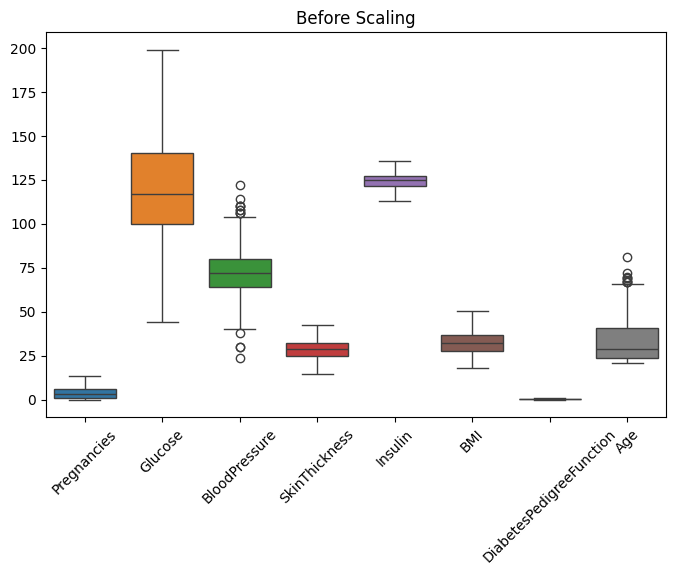

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(data=df.drop("Outcome", axis=1))
plt.title("Before Scaling")
plt.xticks(rotation=45)
plt.show()


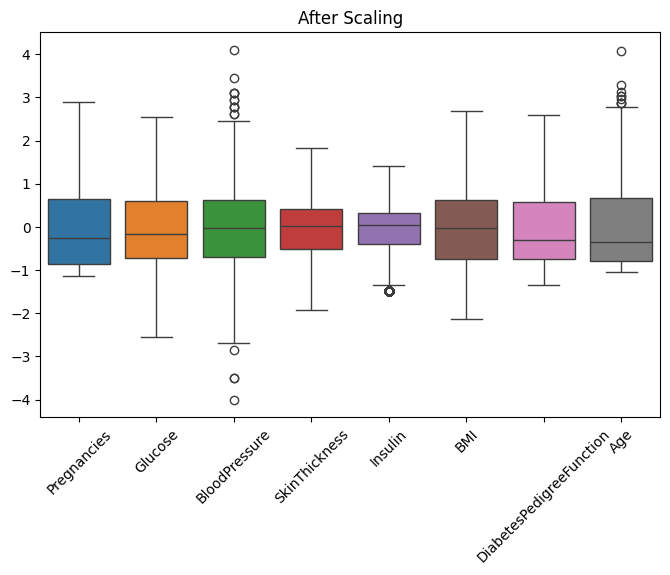

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_scaled.drop("Outcome", axis=1))
plt.title("After Scaling")
plt.xticks(rotation=45)
plt.show()


# Documentation table

In [ ]:
summary = pd.DataFrame({
    "Step": [
        "Replaced zeros with NaN",
        "Filled missing values with Median",
        "Outlier treatment using IQR",
        "Feature Scaling using StandardScaler"
    ],
    "Description": [
        "Converted invalid zero values to NaN",
        "Replaced missing values with column median",
        "Clipped extreme values using IQR method",
        "Standardized numerical features"
    ]
})

summary


,Step,Description
0,Replaced zeros with NaN,Converted invalid zero values to NaN
1,Filled missing values with Median,Replaced missing values with column median
2,Outlier treatment using IQR,Clipped extreme values using IQR method
3,Feature Scaling using StandardScaler,Standardized numerical features


# Prepared by :
# Zaina Akram Hassouna
# Sara Ahmed Al-shorafa
# Leena Nehad Al-Wer